=== N=10 ===
digit 0: min pairwise distance = 2.070
digit 1: min pairwise distance = 0.938
digit 2: min pairwise distance = 1.778
digit 3: min pairwise distance = 1.924
digit 4: min pairwise distance = 2.500
digit 5: min pairwise distance = 2.500
digit 6: min pairwise distance = 2.362
digit 7: min pairwise distance = 1.458
digit 8: min pairwise distance = 2.625
digit 9: min pairwise distance = 2.362


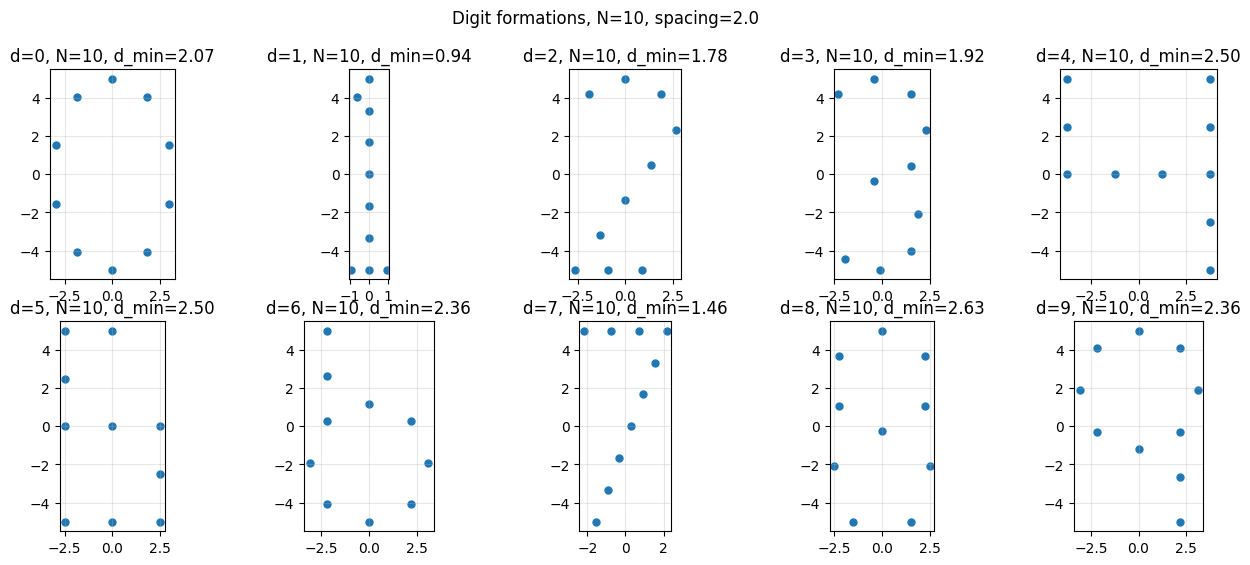

=== N=15 ===
digit 0: min pairwise distance = 1.977
digit 1: min pairwise distance = 0.938
digit 2: min pairwise distance = 1.951
digit 3: min pairwise distance = 2.085
digit 4: min pairwise distance = 1.935
digit 5: min pairwise distance = 2.500
digit 6: min pairwise distance = 1.944
digit 7: min pairwise distance = 1.602
digit 8: min pairwise distance = 2.663
digit 9: min pairwise distance = 1.944


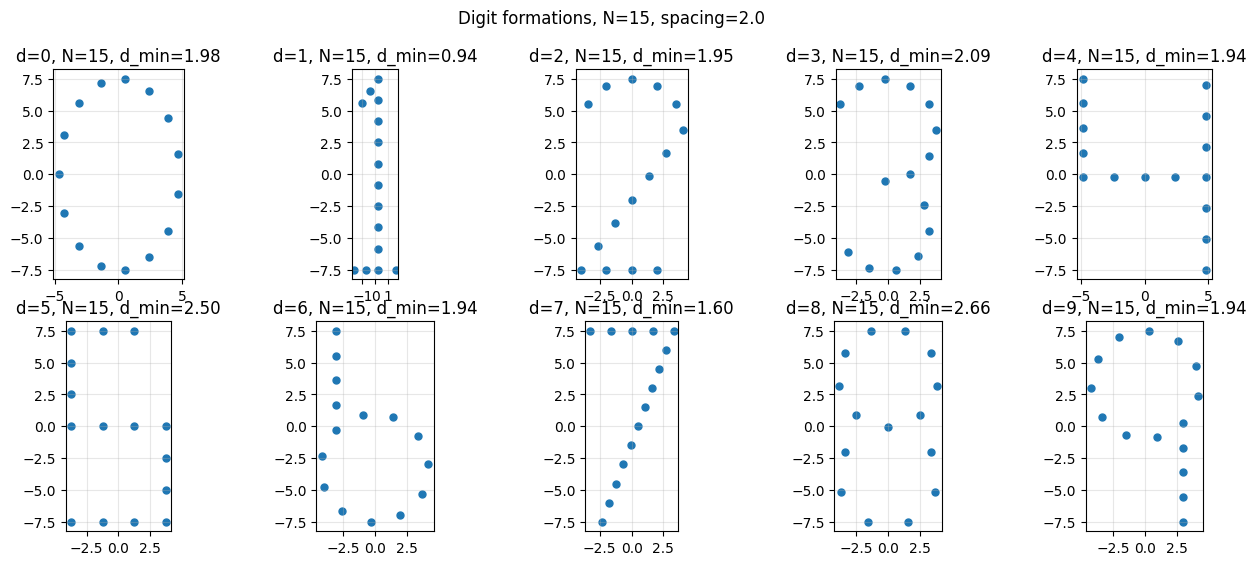

=== N=20 ===
digit 0: min pairwise distance = 1.980
digit 1: min pairwise distance = 0.960
digit 2: min pairwise distance = 2.000
digit 3: min pairwise distance = 2.087
digit 4: min pairwise distance = 2.041
digit 5: min pairwise distance = 2.500
digit 6: min pairwise distance = 2.118
digit 7: min pairwise distance = 1.538
digit 8: min pairwise distance = 2.620
digit 9: min pairwise distance = 2.118


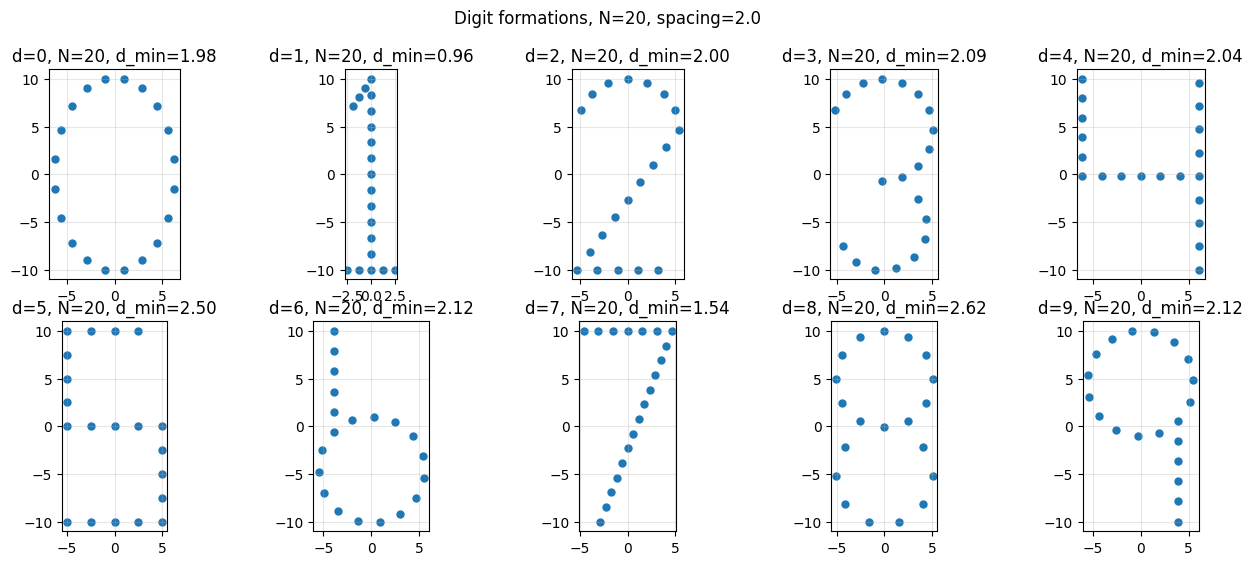

=== N=25 ===
digit 0: min pairwise distance = 1.968
digit 1: min pairwise distance = 0.925
digit 2: min pairwise distance = 2.037
digit 3: min pairwise distance = 2.060
digit 4: min pairwise distance = 2.113
digit 5: min pairwise distance = 2.500
digit 6: min pairwise distance = 2.047
digit 7: min pairwise distance = 1.476
digit 8: min pairwise distance = 2.782
digit 9: min pairwise distance = 2.047


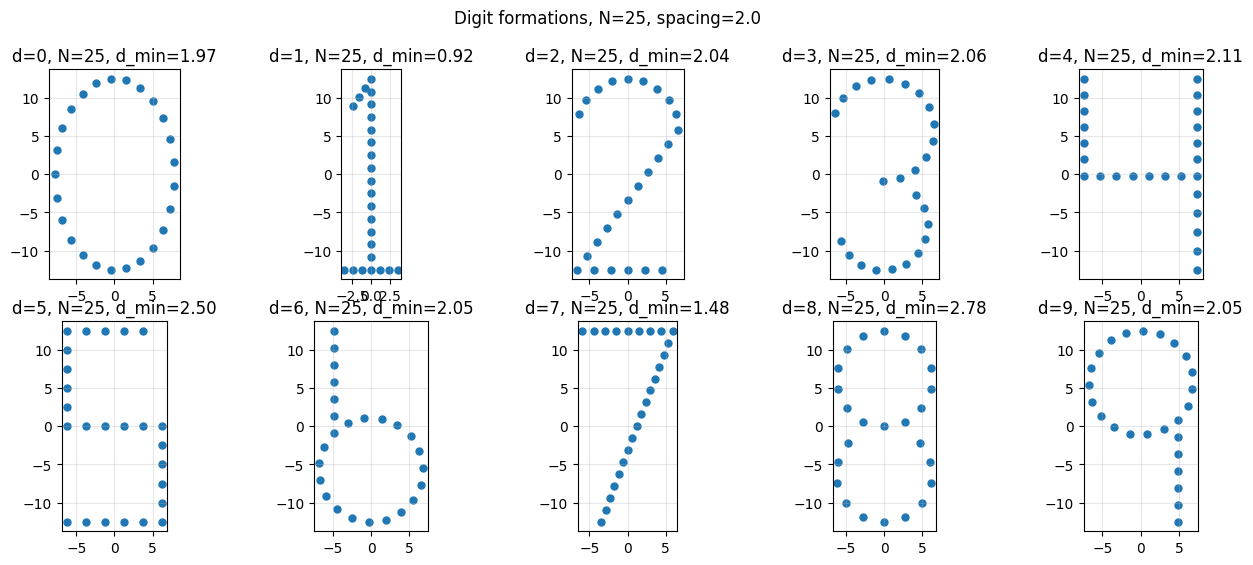

=== N=30 ===
digit 0: min pairwise distance = 1.977
digit 1: min pairwise distance = 0.877
digit 2: min pairwise distance = 1.956
digit 3: min pairwise distance = 2.116
digit 4: min pairwise distance = 2.143
digit 5: min pairwise distance = 2.500
digit 6: min pairwise distance = 1.947
digit 7: min pairwise distance = 1.575
digit 8: min pairwise distance = 2.768
digit 9: min pairwise distance = 1.947


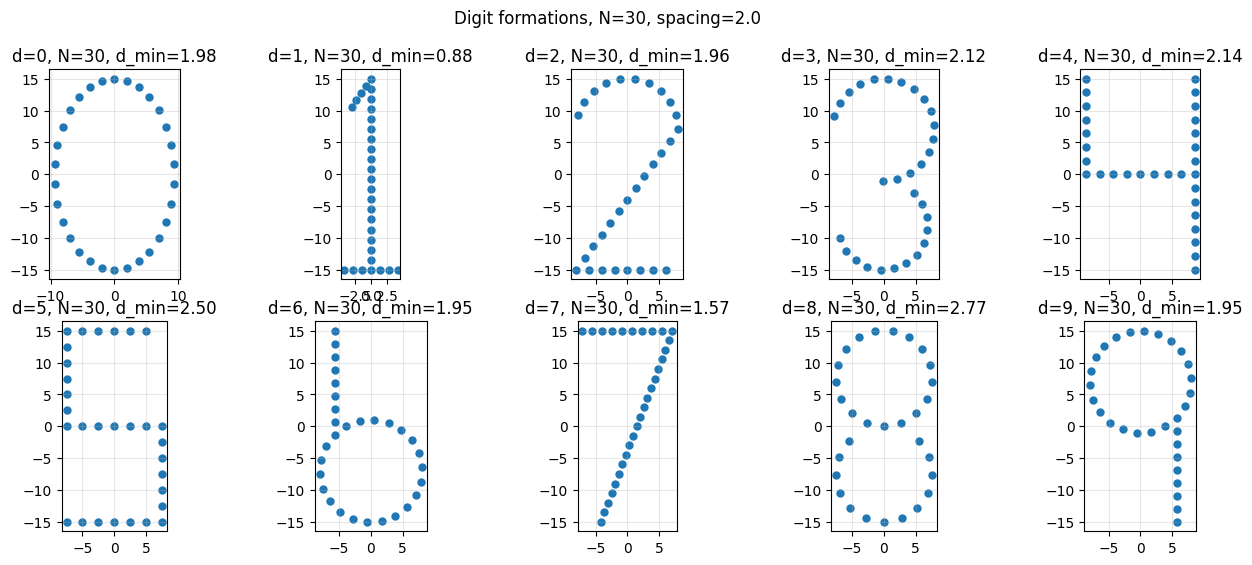

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Repo root = gnn_drone_project (parent of merged_work)
ROOT = Path.cwd()
if (ROOT / "merged_work").exists():
    pass
elif (ROOT.parent / "merged_work").exists():
    ROOT = ROOT.parent
elif (ROOT.parent.parent / "merged_work").exists():
    ROOT = ROOT.parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from merged_work.models_creation.digit_formations import (
    min_pairwise_distance_xy,
    sample_digit_offsets,
)


def plot_digit(digit: int, num_drones: int, ax: plt.Axes, spacing: float = 2.0) -> None:
    offsets = sample_digit_offsets(digit=digit, num_drones=num_drones, spacing=spacing)
    xy = offsets[:, :2]
    d_min = min_pairwise_distance_xy(xy)
    ax.scatter(xy[:, 0], xy[:, 1], c="tab:blue", s=25)
    ax.set_aspect("equal")
    ax.set_title(f"d={digit}, N={num_drones}, d_min={d_min:.2f}")
    ax.grid(True, alpha=0.3)


def visualize_all_digits(drone_counts=(10, 15, 20, 25, 30), spacing: float = 2.0):
    for N in drone_counts:
        fig, axes = plt.subplots(2, 5, figsize=(16, 6))
        axes = axes.ravel()
        print(f"=== N={N} ===")
        for d in range(10):
            offsets = sample_digit_offsets(digit=d, num_drones=N, spacing=spacing)
            xy = offsets[:, :2]
            d_min = min_pairwise_distance_xy(xy)
            print(f"digit {d}: min pairwise distance = {d_min:.3f}")
            plot_digit(d, N, axes[d], spacing=spacing)
        fig.suptitle(f"Digit formations, N={N}, spacing={spacing}")
        plt.show()


if __name__ == "__main__":
    visualize_all_digits()


In [2]:
import numpy as np

from merged_work.models_creation.digit_formations import (
    min_pairwise_distance_xy,
    sample_digit_offsets,
)

# Quick assertions for N in 10..30 (0.4*spacing matches validate_digits-style floor)
spacing = 2.0
tol = 1e-3
threshold = 0.4 * spacing - tol
for N in range(10, 31):
    for d in range(10):
        offsets = sample_digit_offsets(digit=d, num_drones=N, spacing=spacing)
        assert offsets.shape == (N, 3)
        assert np.all(np.isfinite(offsets))
        xy = offsets[:, :2]
        d_min = min_pairwise_distance_xy(xy)
        assert d_min >= threshold, f"digit {d}, N={N}, d_min={d_min:.3f} too small"
print("All digits 0-9 passed spacing checks for N=10..30")

AssertionError: digit 1, N=10, d_min=0.938 too small